<a href="https://colab.research.google.com/github/shhjosh02/trabajo-final-sistema-predictivo/blob/main/notebooks/01_EDA_y_Limpieza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Colab conectado. Directorio actual: /content/drive/MyDrive/Proyecto_IA/notebooks
✅ Librerías cargadas exitosamente
✅ Dataset cargado: 18693 filas, 9 columnas
✅ Nuevas características numéricas añadidas.

📊 GRÁFICO 1: DISTRIBUCIÓN DE TENDENCIAS (LABEL)
📌 QUÉ SE OBSERVA:
• Permite identificar el balance o desbalance de clases en la variable objetivo ('Label').
• Muestra la frecuencia relativa entre días alcistas (1), bajistas (0) u otras categorías.
• Ayuda a determinar si se requieren técnicas de resampleo o métricas especiales (F1-score, ROC-AUC) durante el modelado.



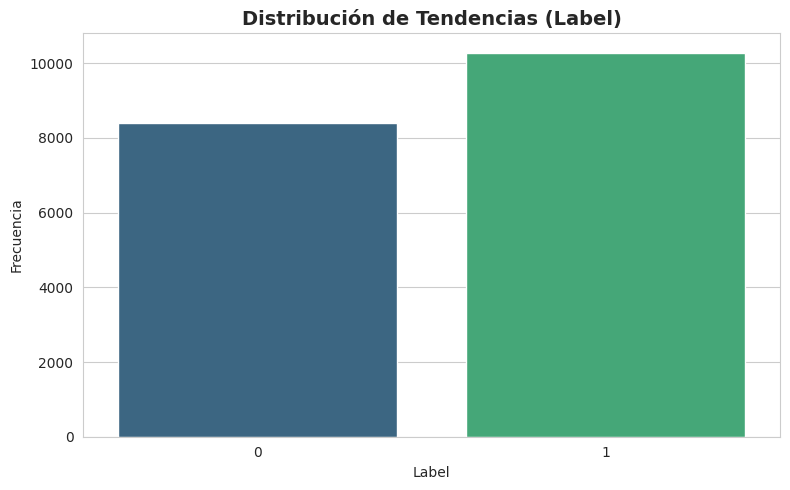


📊 GRÁFICO 2: VOLUMEN DE NEGOCIACIÓN POR TICKER (ESCALA LOGARÍTMICA)
📌 QUÉ SE DEBE OBSERVAR EN TICKER:
• Compara la distribución del volumen de transacciones entre los distintos activos financieros (Tickers).
• Nivel de Liquidez: Permite ver qué activos manejan mayor volumen de mercado y cuáles son menos líquidos.
• Dispersión y Outliers: La amplitud de las cajas y los puntos flotantes muestran la variabilidad diaria y días atípicos de alta negociación.
• Escala Logarítmica: Permite comparar tickers con diferencias masivas en volumen sin distorsionar la visualización.



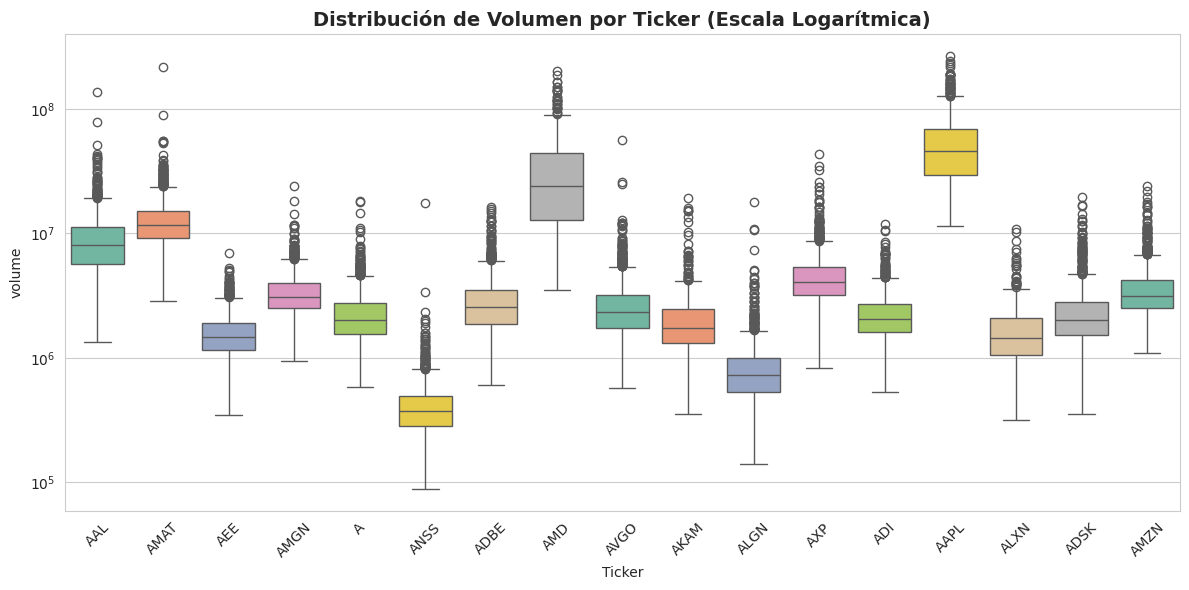


📊 GRÁFICO 3: VOLATILIDAD INTRADÍA VS RETORNO DIARIO
📌 QUÉ SE OBSERVA:
• Evalúa la relación entre el rango de oscilación del precio (volatilidad intradía) y el retorno final del día.
• Permite verificar si jornadas con alta volatilidad coinciden con retornos extremos o tendencias específicas (Label).
• Facilita la identificación de patrones de riesgo y clusters de comportamiento según la tendencia del activo.



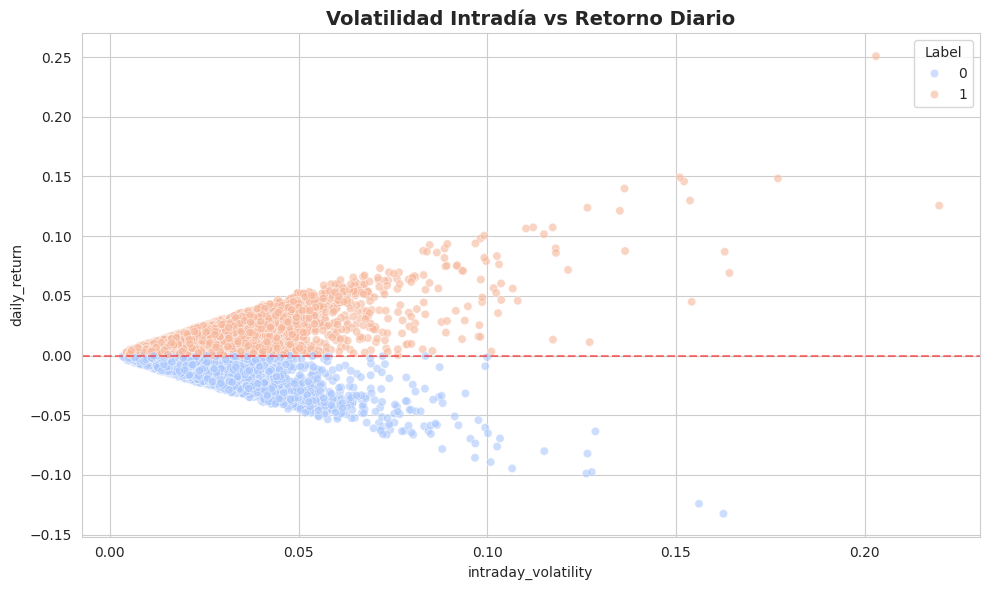


⏳ Procesando texto de las noticias...
✅ Limpieza de texto completada.

📊 GRÁFICO 4: MATRIZ DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS Y LABEL
📌 QUÉ SE OBSERVA:
• Cuantifica la relación lineal directa o inversa entre las variables numéricas y la variable objetivo.
• Multicolinealidad: Detecta si existen variables altamente correlacionadas entre sí (ej. price_range con intraday_volatility).
• Relevancia de Predictores: Permite observar cuáles variables numéricas aportan mayor señal directa al Label.



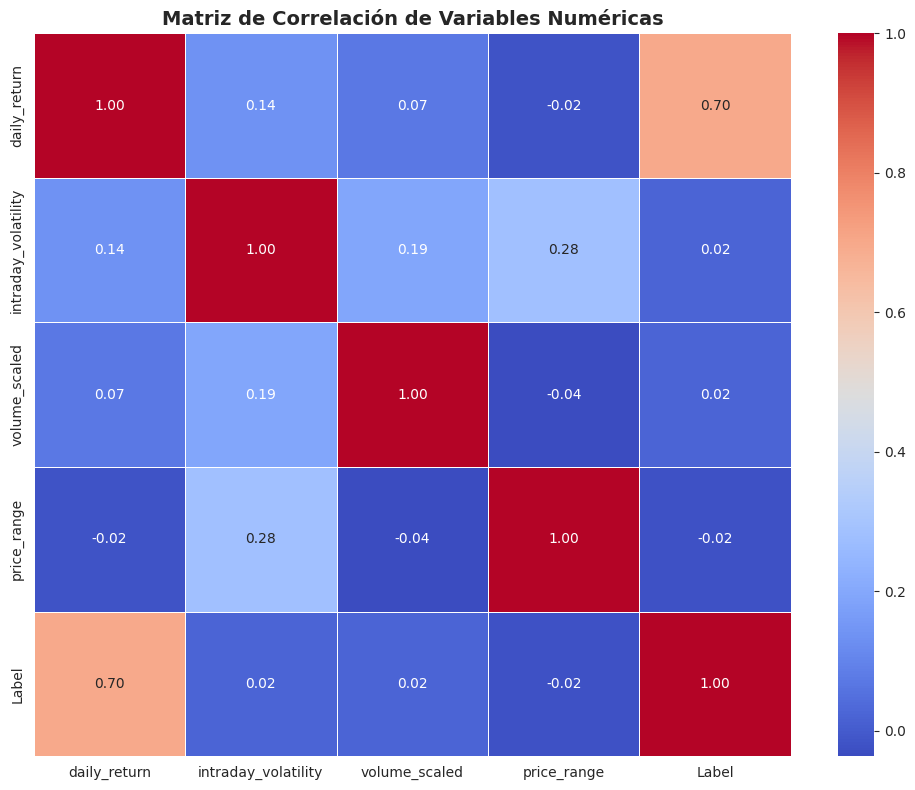


✅ Dataset procesado guardado exitosamente en ../data/dataset_procesado.csv


In [4]:
# =========================================================
# BLOQUE DE PORTABILIDAD: Colab + Drive + Local
# =========================================================
import os
import sys

EN_COLAB = 'google.colab' in sys.modules
CARPETA_DRIVE = 'Proyecto_IA'

if EN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    ruta_notebooks = f'/content/drive/MyDrive/{CARPETA_DRIVE}/notebooks'
    os.chdir(ruta_notebooks)
    print(f"✅ Colab conectado. Directorio actual: {os.getcwd()}")
else:
    print(f"✅ Ejecutando en Local. Directorio actual: {os.getcwd()}")

# Asegurar carpeta de gráficos
os.makedirs('../outputs/graficos', exist_ok=True)

# -*- coding: utf-8 -*-
"""
ANÁLISIS EXPLORATORIO DE DATOS FINANCIEROS
FASE 1: CARGA, LIMPIEZA Y EDA
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("✅ Librerías cargadas exitosamente")

# 2. CARGAR DATOS
df = pd.read_csv('../data/dataset_final_para_modelos(modificado).csv', sep=';', encoding='latin-1')

if 'ï»¿date' in df.columns:
    df.rename(columns={'ï»¿date': 'date'}, inplace=True)

df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y', errors='coerce')
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

print(f"✅ Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

# 3. INGENIERÍA DE CARACTERÍSTICAS
df['daily_return'] = (df['close'] - df['open']) / df['open']
df['intraday_volatility'] = (df['high'] - df['low']) / df['close']
df['volume_scaled'] = df['volume'] / df['volume'].max()
df['price_range'] = df['high'] - df['low']
print("✅ Nuevas características numéricas añadidas.")

# =========================================================
# 4. GRÁFICO 1: DISTRIBUCIÓN DEL LABEL
# =========================================================
print("\n" + "="*75)
print("📊 GRÁFICO 1: DISTRIBUCIÓN DE TENDENCIAS (LABEL)")
print("="*75)
print("📌 QUÉ SE OBSERVA:")
print("• Permite identificar el balance o desbalance de clases en la variable objetivo ('Label').")
print("• Muestra la frecuencia relativa entre días alcistas (1), bajistas (0) u otras categorías.")
print("• Ayuda a determinar si se requieren técnicas de resampleo o métricas especiales (F1-score, ROC-AUC) durante el modelado.")
print("="*75 + "\n")

plt.figure(figsize=(8, 5))
sns.countplot(x='Label', data=df, palette='viridis')
plt.title('Distribución de Tendencias (Label)', fontsize=14, fontweight='bold')
plt.xlabel('Label')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('../outputs/graficos/distribucion_label.png', dpi=300)
plt.show()

# =========================================================
# 5. GRÁFICO 2: VOLUMEN POR TICKER
# =========================================================
print("\n" + "="*75)
print("📊 GRÁFICO 2: VOLUMEN DE NEGOCIACIÓN POR TICKER (ESCALA LOGARÍTMICA)")
print("="*75)
print("📌 QUÉ SE DEBE OBSERVAR EN TICKER:")
print("• Compara la distribución del volumen de transacciones entre los distintos activos financieros (Tickers).")
print("• Nivel de Liquidez: Permite ver qué activos manejan mayor volumen de mercado y cuáles son menos líquidos.")
print("• Dispersión y Outliers: La amplitud de las cajas y los puntos flotantes muestran la variabilidad diaria y días atípicos de alta negociación.")
print("• Escala Logarítmica: Permite comparar tickers con diferencias masivas en volumen sin distorsionar la visualización.")
print("="*75 + "\n")

plt.figure(figsize=(12, 6))
sns.boxplot(x='Ticker', y='volume', data=df, palette='Set2')
plt.title('Distribución de Volumen por Ticker (Escala Logarítmica)', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/graficos/volumen_por_ticker.png', dpi=300)
plt.show()

# =========================================================
# 6. GRÁFICO 3: VOLATILIDAD VS RETORNO
# =========================================================
print("\n" + "="*75)
print("📊 GRÁFICO 3: VOLATILIDAD INTRADÍA VS RETORNO DIARIO")
print("="*75)
print("📌 QUÉ SE OBSERVA:")
print("• Evalúa la relación entre el rango de oscilación del precio (volatilidad intradía) y el retorno final del día.")
print("• Permite verificar si jornadas con alta volatilidad coinciden con retornos extremos o tendencias específicas (Label).")
print("• Facilita la identificación de patrones de riesgo y clusters de comportamiento según la tendencia del activo.")
print("="*75 + "\n")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='intraday_volatility', y='daily_return', hue='Label', data=df, alpha=0.6, palette='coolwarm')
plt.title('Volatilidad Intradía vs Retorno Diario', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../outputs/graficos/volatilidad_vs_retorno.png', dpi=300)
plt.show()

# 7. PREPROCESAMIENTO DE TEXTO
print("\n⏳ Procesando texto de las noticias...")
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('spanish'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['text_clean'] = df['Headline_esp'].astype(str).apply(clean_text)
print("✅ Limpieza de texto completada.")

# =========================================================
# 8. GRÁFICO 4: MATRIZ DE CORRELACIÓN
# =========================================================
print("\n" + "="*75)
print("📊 GRÁFICO 4: MATRIZ DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS Y LABEL")
print("="*75)
print("📌 QUÉ SE OBSERVA:")
print("• Cuantifica la relación lineal directa o inversa entre las variables numéricas y la variable objetivo.")
print("• Multicolinealidad: Detecta si existen variables altamente correlacionadas entre sí (ej. price_range con intraday_volatility).")
print("• Relevancia de Predictores: Permite observar cuáles variables numéricas aportan mayor señal directa al Label.")
print("="*75 + "\n")

plt.figure(figsize=(10, 8))
corr = df[['daily_return', 'intraday_volatility', 'volume_scaled', 'price_range', 'Label']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/graficos/matriz_correlacion.png', dpi=300)
plt.show()

# 9. GUARDAR DATASET PROCESADO
df.to_csv('../data/dataset_procesado.csv', sep=';')
print("\n✅ Dataset procesado guardado exitosamente en ../data/dataset_procesado.csv")